In [ ]:
!pip install numpy pandas matplotlib scikit-learn tensorflow


In [ ]:
import pandas as pd

data = pd.read_csv("ph_dengue_cases2016-2020.csv")

data.head()


,Month,Year,Region,Dengue_Cases,Dengue_Deaths
0,January,2016,Region I,705,1
1,February,2016,Region I,374,0
2,March,2016,Region I,276,0
3,April,2016,Region I,240,2
4,May,2016,Region I,243,1


In [ ]:
print(data.columns)


Index(['Month', 'Year', 'Region', 'Dengue_Cases', 'Dengue_Deaths'], dtype='object')


In [ ]:
cases = data["Dengue_Cases"].values.reshape(-1,1)


In [ ]:
print(cases.shape)

(1020, 1)


In [ ]:
print(cases[:5])

[[705]
 [374]
 [276]
 [240]
 [243]]


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
cases_scaled = scaler.fit_transform(cases)



In [ ]:
import numpy as np

def create_dataset(data, time_step=4):
    X, y = [], []
    for i in range(len(data)-time_step):
        X.append(data[i:i+time_step])
        y.append(data[i+time_step])
    return np.array(X), np.array(y)

X, y = create_dataset(cases_scaled, 4)

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (1016, 4, 1)
y shape: (1016, 1)


In [ ]:
# 80% training, 20% testing
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 812
Testing samples: 204


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential()
model.add(LSTM(50, input_shape=(3,1)))  # 3 months input
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.fit(X_train, y_train, epochs=30, batch_size=4)


Epoch 1/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0052
Epoch 2/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0035
Epoch 3/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0028
Epoch 4/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0024
Epoch 5/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0021
Epoch 6/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0029
Epoch 7/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0028
Epoch 8/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0020
Epoch 9/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0021
Epoch 10/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0018
Epoch 11/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0014
Epoch 12/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0010
Epoch 13/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0019
Epoch 14/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0015
Epoch 15/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - lo

In [ ]:
predictions = model.predict(X_test)

# Convert back to original values
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test)

print(predictions[:5])


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step
[[2767.5044  ]
 [1506.678   ]
 [1837.8286  ]
 [ 503.31223 ]
 [ -26.715569]]


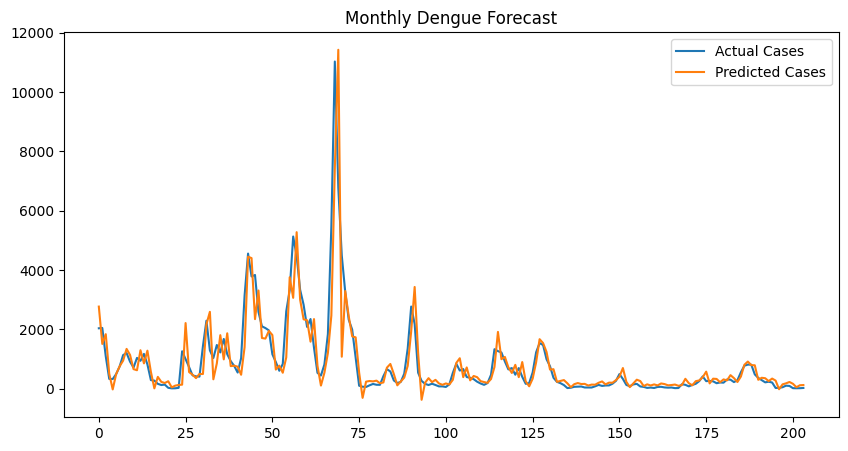

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test_actual, label="Actual Cases")
plt.plot(predictions, label="Predicted Cases")
plt.legend()
plt.title("Monthly Dengue Forecast")
plt.show()
